<!-- portfolio-intro -->
# Портфельный кейс: классификация токсичных комментариев

Этот ноутбук оформлен как портфельное NLP-исследование:

- подготовка и очистка текстовых данных;
- сравнение нескольких подходов к векторизации и классификации;
- интерпретация качества модели на языке продуктовой и бизнес-задачи.

Из ноутбука убрана зависимость от Google Colab. Теперь он сначала ищет данные в локальной папке `data/`, а затем в старом учебном пути `/datasets/`.


<h1>Содержание<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Загрузка-фреймворков" data-toc-modified-id="Загрузка-фреймворков-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Загрузка фреймворков</a></span></li><li><span><a href="#Импорты" data-toc-modified-id="Импорты-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Импорты</a></span></li><li><span><a href="#Чтение-данных" data-toc-modified-id="Чтение-данных-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Чтение данных</a></span></li><li><span><a href="#Подготовка-текста" data-toc-modified-id="Подготовка-текста-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Подготовка текста</a></span><ul class="toc-item"><li><span><a href="#Лемматизация" data-toc-modified-id="Лемматизация-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Лемматизация</a></span></li><li><span><a href="#Частотный-анализ-текста" data-toc-modified-id="Частотный-анализ-текста-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Частотный анализ текста</a></span></li><li><span><a href="#&quot;Облако-слов&quot;" data-toc-modified-id="&quot;Облако-слов&quot;-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>"Облако слов"</a></span></li><li><span><a href="#Баланс-классов" data-toc-modified-id="Баланс-классов-4.4"><span class="toc-item-num">4.4&nbsp;&nbsp;</span>Баланс классов</a></span></li></ul></li><li><span><a href="#Пайплан-векторизации-признаков,-подбора-гиперпараметров-и-валидации-модели-логистической-регрессии" data-toc-modified-id="Пайплан-векторизации-признаков,-подбора-гиперпараметров-и-валидации-модели-логистической-регрессии-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Пайплан векторизации признаков, подбора гиперпараметров и валидации модели логистической регрессии</a></span></li><li><span><a href="#Обучение-модели-логистической-регрессии" data-toc-modified-id="Обучение-модели-логистической-регрессии-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>Обучение модели логистической регрессии</a></span><ul class="toc-item"><li><span><a href="#Признаки---BOW" data-toc-modified-id="Признаки---BOW-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>Признаки - BOW</a></span></li><li><span><a href="#Признаки---TF-IDF" data-toc-modified-id="Признаки---TF-IDF-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Признаки - TF-IDF</a></span></li></ul></li><li><span><a href="#Оценка-качества-модели-логистической-регрессии" data-toc-modified-id="Оценка-качества-модели-логистической-регрессии-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Оценка качества модели логистической регрессии</a></span></li><li><span><a href="#Пайплaйн-векторизации-признаков,-обучения-и-валидации-модели,-на-основе-градиентного-бустинга" data-toc-modified-id="Пайплaйн-векторизации-признаков,-обучения-и-валидации-модели,-на-основе-градиентного-бустинга-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Пайплaйн векторизации признаков, обучения и валидации модели, на основе градиентного бустинга</a></span></li><li><span><a href="#Обучение-модели,-на-основе-градиентного-бустинга" data-toc-modified-id="Обучение-модели,-на-основе-градиентного-бустинга-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Обучение модели, на основе градиентного бустинга</a></span><ul class="toc-item"><li><span><a href="#Признаки---BOW" data-toc-modified-id="Признаки---BOW-9.1"><span class="toc-item-num">9.1&nbsp;&nbsp;</span>Признаки - BOW</a></span></li><li><span><a href="#Признаки----TF-IDF" data-toc-modified-id="Признаки----TF-IDF-9.2"><span class="toc-item-num">9.2&nbsp;&nbsp;</span>Признаки -  TF-IDF</a></span></li></ul></li><li><span><a href="#Оценка-качества-модели,-на-основе-градиентного-бустинга" data-toc-modified-id="Оценка-качества-модели,-на-основе-градиентного-бустинга-10"><span class="toc-item-num">10&nbsp;&nbsp;</span>Оценка качества модели, на основе градиентного бустинга</a></span></li><li><span><a href="#BERT" data-toc-modified-id="BERT-11"><span class="toc-item-num">11&nbsp;&nbsp;</span>BERT</a></span><ul class="toc-item"><li><span><a href="#Получение-признаков-из-текста" data-toc-modified-id="Получение-признаков-из-текста-11.1"><span class="toc-item-num">11.1&nbsp;&nbsp;</span>Получение признаков из текста</a></span></li><li><span><a href="#Пайплайн-векторизации,-обучения-и-валидации-моделей" data-toc-modified-id="Пайплайн-векторизации,-обучения-и-валидации-моделей-11.2"><span class="toc-item-num">11.2&nbsp;&nbsp;</span>Пайплайн векторизации, обучения и валидации моделей</a></span></li><li><span><a href="#Обучение-моделей" data-toc-modified-id="Обучение-моделей-11.3"><span class="toc-item-num">11.3&nbsp;&nbsp;</span>Обучение моделей</a></span><ul class="toc-item"><li><span><a href="#Логистическая-регрессия,-признаки---BERT" data-toc-modified-id="Логистическая-регрессия,-признаки---BERT-11.3.1"><span class="toc-item-num">11.3.1&nbsp;&nbsp;</span>Логистическая регрессия, признаки - BERT</a></span></li><li><span><a href="#Модель-на-основе-градиентного-бустинга,-признаки---BERT" data-toc-modified-id="Модель-на-основе-градиентного-бустинга,-признаки---BERT-11.3.2"><span class="toc-item-num">11.3.2&nbsp;&nbsp;</span>Модель на основе градиентного бустинга, признаки - BERT</a></span></li></ul></li><li><span><a href="#Оценка-качества-моделей" data-toc-modified-id="Оценка-качества-моделей-11.4"><span class="toc-item-num">11.4&nbsp;&nbsp;</span>Оценка качества моделей</a></span></li></ul></li><li><span><a href="#Тестирование-оптимальной-модели" data-toc-modified-id="Тестирование-оптимальной-модели-12"><span class="toc-item-num">12&nbsp;&nbsp;</span>Тестирование оптимальной модели</a></span></li><li><span><a href="#Выводы" data-toc-modified-id="Выводы-13"><span class="toc-item-num">13&nbsp;&nbsp;</span>Выводы</a></span></li></ul></div>

# Проект для «Викишоп»

Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

Необходимо обучить модель классифицировать комментарии на позитивные и негативные. В распоряжении имеется набор данных с разметкой о токсичности правок.

Требуется построить модель со значением метрики качества F1 не меньше 0.75. 

## Загрузка фреймворков

In [1]:
!pip install -q nltk

In [2]:
!pip install -q transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 54.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 64.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.3/190.3 KB 23.8 MB/s eta 0:00:00


In [3]:
!pip install -q catboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 MB 22.5 MB/s eta 0:00:00


In [4]:
!pip install -q spacy

In [5]:
!pip install -q tqdm

In [6]:
!pip install -q wordcloud

## Импорты

In [8]:
import re
import time

import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline

import spacy

from catboost import CatBoostClassifier

from tqdm import tqdm
from tqdm import notebook
from tqdm.auto import tqdm
tqdm.pandas()

import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize
from nltk.probability import FreqDist

import torch
from transformers import AutoModel, AutoTokenizer

from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [9]:
nltk.download('omw-1.4')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [10]:
stopwords = set(stopwords.words('english'))

## Чтение данных

In [ ]:
from pathlib import Path

candidate_paths = [
    Path('data/toxic_comments.csv'),
    Path('/datasets/toxic_comments.csv'),
    Path('/content/drive/MyDrive/Datasets/toxic_comments.csv'),
]

dataset_path = next((path for path in candidate_paths if path.exists()), None)

if dataset_path is None:
    raise FileNotFoundError(
        'Не найден toxic_comments.csv. Скачайте датасет по ссылке ' 
        'https://code.s3.yandex.net/datasets/toxic_comments.csv ' 
        'и сохраните его в data/toxic_comments.csv.'
    )

data = pd.read_csv(dataset_path, index_col=0)


In [14]:
print(f'Количество комментариев: {data.shape[0]}.')
data.head()

Количество комментариев: 159292.


,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


На эксперимент представлено 159 тыс. комментариев пользователей.

## Подготовка текста

### Лемматизация

Подготовим текст к векторизации. Исключим заменим прописные буквы строчными, исключим двойные пробелы, оставим тексте только англоязычные буквы. Слова приведем к лемме.

In [16]:
nlp = spacy.load("en_core_web_sm")

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text

def lemmatize_text(text):
    preprocessed_text = preprocess_text(text)
    doc = nlp(preprocessed_text)
    lemmas = [token.lemma_ for token in doc]
    return ' '.join(lemmas)

In [18]:
%%time

data['text_lemmatized'] = data['text'].progress_apply(lemmatize_text)

  0%|          | 0/159292 [00:00<?, ?it/s]

CPU times: user 37min 7s, sys: 11.9 s, total: 37min 19s
Wall time: 36min 59s


In [19]:
data.head()

,text,toxic,text_lemmatized
0,Explanation\nWhy the edits made under my usern...,0,explanation why the edit make under my usernam...
1,D'aww! He matches this background colour I'm s...,0,daww he match this background colour I m seemi...
2,"Hey man, I'm really not trying to edit war. It...",0,hey man I m really not try to edit war its jus...
3,"""\nMore\nI can't make any real suggestions on ...",0,more I can not make any real suggestion on i...
4,"You, sir, are my hero. Any chance you remember...",0,you sir be my hero any chance you remember wha...


Комметарии подготовлены к созданию признаков для обучения классифкаторов.

### Частотный анализ текста

1. Токенизируем лемматизированный текст:

In [20]:
text_tokens = word_tokenize(' '.join(data['text_lemmatized']))

2. Отчистим текст от "стоп-слов":

In [21]:
filtered_text_tokens = [word for word in text_tokens if word not in stopwords]

3. Список токенов преобразуем к классу Text:

In [22]:
text = nltk.Text(filtered_text_tokens)

4. Для подсчёта статистики распределения частот слов в тексте применим класс FreqDist:

In [23]:
fdist = FreqDist(text)

5.  Класс FreqDist содержит встроенный метод plot для построения графика частот:

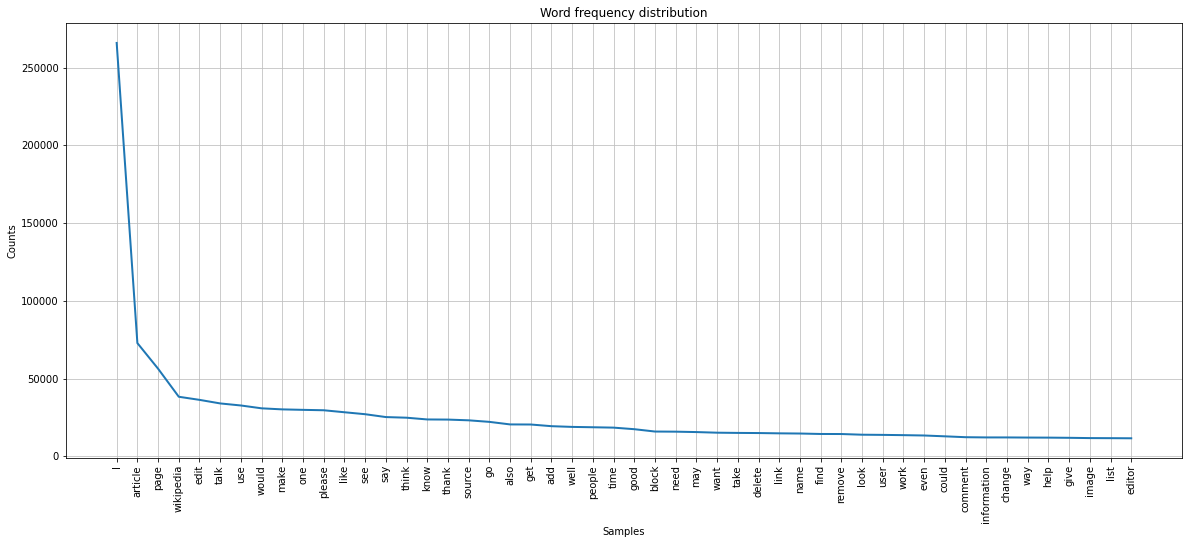

In [24]:
plt.figure(figsize=(20, 8))
fdist.plot(50, cumulative=False, title='Word frequency distribution')
plt.show()

### "Облако слов"

1. Для построения облака слов на вход методу необходимо передать строку. Для преобразования списка токенов после предобработки и удаления стоп-слов воспользуемся методом join, указав в качестве разделителя пробел:

In [25]:
text_raw = ' '.join(text)

2. Выполним вызов метода построения облака:

In [26]:
wordcloud = WordCloud().generate(text_raw)

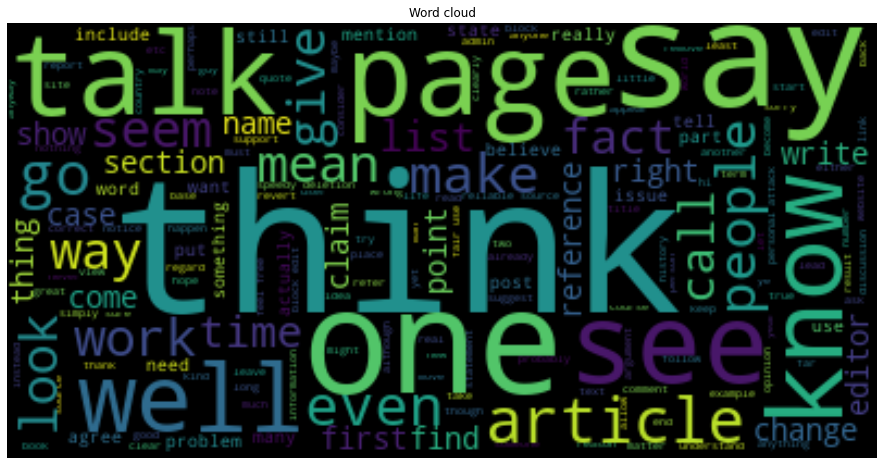

In [27]:
plt.figure(figsize=(20, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word cloud')
plt.show()

### Баланс классов

In [28]:
round(data['toxic'].value_counts(normalize=True).to_frame().T, 2)

,0,1
toxic,0.9,0.1


Имеет место дисбаланс класса в пользу доброжелательных комметнтариев.

## Пайплан векторизации признаков, подбора гиперпараметров и валидации модели логистической регрессии

В методических целях проведем эксперимент и подберем параментры, как диапазона N-грамм при векторизации призанков, так и гиперпараметров для логистической регресии.

1. Создание пайплайнов

Пайплайны созданы для модели логистической регресси. Используются векторизации методами BOW и TF-IDF с перебором занчений N-грамм (рассматриваются биграммы и триграммы).

В модели логистической регресси подбираются параметры регуляризации.

Подбор параметром осуществляется методом перебора по сетке.

In [33]:
lr_clf_bow_pipe = Pipeline([
    ('bow_vectorizer', CountVectorizer(stop_words=stopwords)),
    ('lr_clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_clf_tfidf_pipe = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer(stop_words=stopwords)),
    ('lr_clf', LogisticRegression(max_iter=1000, random_state=42))
])

lr_clf_bow_params = {'lr_clf__C': [.01, .05, .1, .5, 1, 5, 10]}

lr_clf_tfidf_params = {'lr_clf__C': [.01, .05, .1, .5, 1, 5, 10]}



lr_clf_bow_search = GridSearchCV(lr_clf_bow_pipe, lr_clf_bow_params, cv=3, scoring='f1')
lr_clf_tfidf_search = GridSearchCV(lr_clf_tfidf_pipe, lr_clf_tfidf_params, cv=3, scoring='f1')

In [34]:
text_train, text_test, labels_train, labels_test = train_test_split(data['text_lemmatized'], 
                                                                    data['toxic'], 
                                                                    test_size=.2, 
                                                                    stratify=data['toxic'], 
                                                                    random_state=42)

## Обучение модели логистической регрессии

### Признаки - BOW

In [35]:
%%time

lr_clf_bow_search.fit(text_train, labels_train)

CPU times: user 26min 26s, sys: 1h 30min 45s, total: 1h 57min 12s
Wall time: 12min 10s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('bow_vectorizer',
                                        CountVectorizer(stop_words={'a',
                                                                    'about',
                                                                    'above',
                                                                    'after',
                                                                    'again',
                                                                    'against',
                                                                    'ain',
                                                                    'all', 'am',
                                                                    'an', 'and',
                                                                    'any',
                                                                    'are',
                                                                    'aren',


### Признаки - TF-IDF

In [36]:
%%time

lr_clf_tfidf_search.fit(text_train, labels_train)

CPU times: user 8min 33s, sys: 23min 6s, total: 31min 39s
Wall time: 4min 47s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf_vectorizer',
                                        TfidfVectorizer(stop_words={'a',
                                                                    'about',
                                                                    'above',
                                                                    'after',
                                                                    'again',
                                                                    'against',
                                                                    'ain',
                                                                    'all', 'am',
                                                                    'an', 'and',
                                                                    'any',
                                                                    'are',
                                                                    'aren'

## Оценка качества модели логистической регрессии

In [37]:
print(f'LogisticRegression CountVectorizer F1-score: {lr_clf_bow_search.best_score_:.2f}')
print('LogisticRegression CountVectorizer оптимальные гиперпараметры: ', lr_clf_bow_search.best_params_)
print()
print(f'LogisticRegression TfidfVectorizer F1-score: {lr_clf_tfidf_search.best_score_:.2f}')
print('LogisticRegression TfidfVectorizer оптимальные гиперпараметры: ', lr_clf_tfidf_search.best_params_)

LogisticRegression CountVectorizer F1-score: 0.76
LogisticRegression CountVectorizer оптимальные гиперпараметры:  {'lr_clf__C': 5}

LogisticRegression TfidfVectorizer F1-score: 0.77
LogisticRegression TfidfVectorizer оптимальные гиперпараметры:  {'lr_clf__C': 10}


Обучение логистической регресси на векторах BOW дало оптимальный результат, как по скрости обучения, так и по метрике качества.

Таким образом, для решения задачи Проекта целесообразно в качестве классификатора использовать логистическую регрессию на признаках - BOW.

Продолжим эксперимент.

## Пайплaйн векторизации признаков, обучения и валидации модели, на основе градиентного бустинга

Используем пайплан без подбора значений диапазона N-грамм и гиперпарметров модели. Значение N-грамм и гиперпараметров моделей используем дефолтные.

Пайплан используем для исключения утечки данных при обучении векторайзеров и трансформации текста.

In [48]:
cb_clf_bow_pipe = Pipeline([
    ('bow_vectorizer', CountVectorizer(stop_words=stopwords)),
    ('cb_clf', CatBoostClassifier(silent=True, task_type='GPU', random_seed=42))
])

cb_clf_tfidf_pipe = Pipeline([
    ('tfidf_vectorizer', TfidfVectorizer(stop_words=stopwords)),
    ('cb_clf', CatBoostClassifier(silent=True, task_type='GPU', random_seed=42))
])

cb_clf_bow_params = {}

cb_clf_tfidf_params = {}

cb_clf_bow_search = GridSearchCV(cb_clf_bow_pipe, cb_clf_bow_params, cv=3, scoring='f1')
cb_clf_tfidf_search = GridSearchCV(cb_clf_tfidf_pipe, cb_clf_tfidf_params, cv=3, scoring='f1')

## Обучение модели, на основе градиентного бустинга

### Признаки - BOW

In [49]:
%%time

cb_clf_bow_search.fit(text_train, labels_train)

CPU times: user 21min 43s, sys: 3min 32s, total: 25min 15s
Wall time: 4min 7s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('bow_vectorizer',
                                        CountVectorizer(stop_words={'a',
                                                                    'about',
                                                                    'above',
                                                                    'after',
                                                                    'again',
                                                                    'against',
                                                                    'ain',
                                                                    'all', 'am',
                                                                    'an', 'and',
                                                                    'any',
                                                                    'are',
                                                                    'aren',


### Признаки -  TF-IDF

In [50]:
%%time

cb_clf_tfidf_search.fit(text_train, labels_train)

CPU times: user 23min 2s, sys: 4min, total: 27min 3s
Wall time: 5min 45s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('tfidf_vectorizer',
                                        TfidfVectorizer(stop_words={'a',
                                                                    'about',
                                                                    'above',
                                                                    'after',
                                                                    'again',
                                                                    'against',
                                                                    'ain',
                                                                    'all', 'am',
                                                                    'an', 'and',
                                                                    'any',
                                                                    'are',
                                                                    'aren'

## Оценка качества модели, на основе градиентного бустинга

In [51]:
print(f'CatBoostClassifier CountVectorizer F1-score: {cb_clf_bow_search.best_score_:.2f}')
print('CatBoostClassifier CountVectorizer оптимальные гиперпараметры: ', cb_clf_bow_search.best_params_)
print()
print(f'CatBoostClassifier TfidfVectorizer F1-score: {cb_clf_tfidf_search.best_score_:.2f}')
print('CatBoostClassifier TfidfVectorizer оптимальные гиперпараметры: ', cb_clf_tfidf_search.best_params_)

CatBoostClassifier CountVectorizer F1-score: 0.67
CatBoostClassifier CountVectorizer оптимальные гиперпараметры:  {}

CatBoostClassifier TfidfVectorizer F1-score: 0.70
CatBoostClassifier TfidfVectorizer оптимальные гиперпараметры:  {}


##  BERT

В качестве эксперимента, веторизуем данные предобученной моделью BERT.

### Получение признаков из текста

1. Определение места проведения расчетов

Для ускорения расчетов воспользуемся графическим процессором.

In [52]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2. Получение токенов из текста

Для токенизации и векторизация текста комментариев будем использовать модель BERTox. 

Это модель BERT, специально разработанная для обработки токсичных комментариев, которая была дообучена на наборе данных с токсичными комментариями. Она может обеспечить лучшие результаты в задачах анализа тональности и классификации токсичных комментариев.

In [54]:
tokenizer = AutoTokenizer.from_pretrained('unitary/toxic-bert')

In [55]:
tokenized = data['text'].apply(lambda x: tokenizer.encode(x, add_special_tokens=True, max_length=512, truncation=True))

Данные токенизированы.

3. Расчет максимальной длины токена

In [56]:
max_len = max([len(i) for i in tokenized.values])

4. Создание маски токенов

In [57]:
padded = np.array([i + [0] * (max_len - len(i)) for i in tokenized.values])

In [58]:
attention_mask = np.where(padded != 0, 1, 0)

Маска токенов создана.

5. Загрузка предобученной модели

In [59]:
model = AutoModel.from_pretrained('unitary/toxic-bert')
model = model.to(device)

Some weights of the model checkpoint at unitary/toxic-bert were not used when initializing BertModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


6. Векторизация токенов

In [60]:
batch_size = 512
embeddings = []
for i in notebook.tqdm(range(padded.shape[0] // batch_size)):
    batch = padded[batch_size * i:batch_size * (i + 1)]
    attention_mask_batch = attention_mask[batch_size * i:batch_size * (i + 1)]
    seq_length = batch.shape[1]
    
    with torch.no_grad():
        batch = torch.LongTensor(batch).to(device)
        attention_mask_batch = torch.LongTensor(attention_mask_batch).to(device)
        batch_embeddings = model(batch, attention_mask=attention_mask_batch)
    
    embeddings.append(batch_embeddings[0][:, 0, :].cpu().numpy())

  0%|          | 0/311 [00:00<?, ?it/s]

Стоит отметить, что во-первых представленные на эксперимент текск был принудительно урезан в процессе токенизации; во-вторых, векторизация проводиться по батчам в виду ограниченности имеющихся ресурсов, в связи с чем часть данных (наблюдений) потерена.

Таким образом, использщование модели BERT для векторизации на данном датасете не целесообразно и рассматривается из методических целей.

7. Получение признаков и лейблов

In [61]:
features = np.concatenate(embeddings)

In [62]:
target = data['toxic'][:features.shape[0]]

8. Сплит данных

In [63]:
bert_text_train, bert_text_test, bert_labels_train, bert_labels_test = train_test_split(features, 
                                                                                        target, 
                                                                                        test_size=.2, 
                                                                                        stratify=target, 
                                                                                        random_state=42)

### Пайплайн векторизации, обучения и валидации моделей

In [64]:
lr_clf_bert_pipe = Pipeline([
    ('lr_clf', LogisticRegression(max_iter=1000, random_state=42))
])

cb_clf_bert_pipe = Pipeline([
    ('cb_clf', CatBoostClassifier(silent=True, task_type='GPU'))
])

lr_clf_bert_params = {}

cb_clf_bert_params = {}

lr_clf_bert_search = GridSearchCV(lr_clf_bert_pipe, lr_clf_bert_params, cv=3, scoring='f1')
cb_clf_bert_search = GridSearchCV(cb_clf_bert_pipe, cb_clf_bert_params, cv=3, scoring='f1')

### Обучение моделей

#### Логистическая регрессия, признаки - BERT

In [67]:
%%time

lr_clf_bert_search.fit(bert_text_train, bert_labels_train)

CPU times: user 20min 7s, sys: 6min 52s, total: 27min
Wall time: 2min 20s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('lr_clf',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             param_grid={}, scoring='f1')

Стоит отметить, что алгоритм оптимизации, используемый в логистической регрессии (L-BFGS), не сошелся к решению задачи, количество итераций, выполненных алгоритмом, достигло максимально допустимого значения.

Решением может быть, как увеличение количествф итераций, так и масштабирование данные.

#### Модель на основе градиентного бустинга, признаки - BERT

In [70]:
%%time

cb_clf_bert_search.fit(bert_text_train, bert_labels_train)

CPU times: user 2min, sys: 27.7 s, total: 2min 28s
Wall time: 52.3 s


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('cb_clf',
                                        <catboost.core.CatBoostClassifier object at 0x7fa567dffe50>)]),
             param_grid={}, scoring='f1')

### Оценка качества моделей

In [71]:
print(f'LogisticRegression BERT F1-score: {lr_clf_bert_search.best_score_:.2f}')
print(f'CatBoostClassifier BERT F1-score: {cb_clf_bert_search.best_score_:.2f}')

LogisticRegression BERT F1-score: 0.95
CatBoostClassifier BERT F1-score: 0.95


## Тестирование оптимальной модели

In [74]:
best_model = lr_clf_bert_search.best_estimator_
labels_pred = best_model.predict(bert_text_test)

print(f'F1_score на тесте: {f1_score(bert_labels_test, labels_pred):.2f}.')

F1_score на тесте: 0.95.


## Выводы

1. Решить поставленую задачу - получить значение метрики качеста F1 более 0,75 смога модель логистической регресии на векторах BOW и TF-IDF со стоп-словами и без N-грамм и модели логистической регресии и градиентного бустинга на векторах BERT.

Тестировалась модель логистической регресии, обученная на векторах BERT. Итоговая метрика F1 - 0,95.

2. В качестве эксперимента на усеченной выборки производилась подборка диапазона N-грамм и гиперпараметров логистической регресси. Изменение диапазона N-грамм и подбор гиперпараметров логистической регресии прироста качества не принес. Модели рассмотрены в методических целях.

3. Вектория методами BOW и TF-IDF целесообразно проводить с использованием пайплайнов для избежания утечки данных при обучении векторайзеров и трансформации текста, что и было реализовано в Проекте. 

4. Векторизация преобученной моедлью BERT на представленном наборе текстов признана не целесообразна из-за "чрезмерной" длинны комментариев и рассмотрена автором в методических целях.

5. Метрики моделей логистической регрессии и градиентного бустинга, обученные на векторах модели BERT показали метрики ниже необходимого уровня в виду усечения, как самого текста в процессе векторизации, так и количества наблюдений. Модели рассмотрены в методических целях.

<!-- portfolio-summary -->
## Краткий итог кейса

Кейс демонстрирует подход к задаче модерации пользовательского контента: от подготовки текста и признаков до сравнения моделей и оценки качества. Репозиторий приведен в портфельный формат и явно показывает, какой датасет нужен для полноценного воспроизведения.
